# House Price Prediction using Linear Regression (Custom CSV Dataset)


## Step 1: Import Libraries


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## Step 2: Create Custom Dataset (20 entries) and Save as CSV


In [18]:
# Create custom dataset
data = {
    "Area": [750, 800, 850, 900, 950, 1000, 1100, 1200, 1300, 1400,
             1500, 1600, 1700, 1800, 1900, 2000, 2200, 2400, 2600, 2800],
    "Price": [75_000, 80_000, 85_000, 90_000, 95_000, 100_000, 110_000, 120_000, 130_000, 140_000,
              150_000, 160_000, 170_000, 180_000, 190_000, 200_000, 220_000, 240_000, 260_000, 280_000],
    "City" : ["Modasa","Himmatnagar","Gandhinagar","Ahmedabad","Surat","Vadodara","Rajkot","Bhavnagar","Jamnagar","Junagadh",
              "Anand","Nadiad","Mehsana","Patan","Surendranagar","Bhuj","Gondal","Morbi","Porbandar","Veraval"],
    "BHK":  [2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6],
    "Age of House": [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv("housing_custom.csv", index=False)

# Show dataset
df


,Area,Price,City,BHK,Age of House
0,750,75000,Modasa,2,5
1,800,80000,Himmatnagar,2,10
2,850,85000,Gandhinagar,2,15
3,900,90000,Ahmedabad,3,20
4,950,95000,Surat,3,25
5,1000,100000,Vadodara,3,30
6,1100,110000,Rajkot,3,35
7,1200,120000,Bhavnagar,4,40
8,1300,130000,Jamnagar,4,45
9,1400,140000,Junagadh,4,50


## Step 3: Load Dataset


In [19]:
df = pd.read_csv("housing_custom.csv")
df.head()


,Area,Price,City,BHK,Age of House
0,750,75000,Modasa,2,5
1,800,80000,Himmatnagar,2,10
2,850,85000,Gandhinagar,2,15
3,900,90000,Ahmedabad,3,20
4,950,95000,Surat,3,25


## Step 4: Define Features and Target


In [20]:
X = df[['Area']]   # independent variable
y = df['Price']    # dependent variable


## Step 5: Split Data into Training and Testing Sets


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 6: Train Linear Regression Model


In [28]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Step 7: Make Predictions


In [29]:
y_pred = model.predict(X_test)


## Step 8: Evaluate Model


In [30]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


Mean Squared Error (MSE): 1.0587911840678754e-22
R² Score: 1.0


## Step 9: Visualization


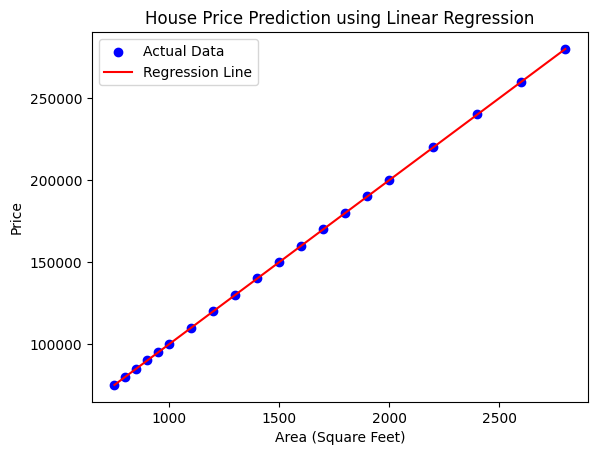

In [31]:
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Price")
plt.title("House Price Prediction using Linear Regression")
plt.legend()
plt.show()


# optional
## Step 10: Predict Price for a Custom Input 

In [ ]:
try:
    user_area = float(input("Enter the area in sq.ft: ")) # 2400
    custom_area = pd.DataFrame([[user_area]], columns=["Area"])
    predicted_price = model.predict(custom_area)[0]

    # Convert price into Lakhs or Crores
    if predicted_price >= 1e7:  # 1 Crore = 10,000,000
        print(f"Predicted price for {user_area:.0f} sq.ft = {predicted_price / 1e7:.2f} Cr")
    else:
        print(f"Predicted price for {user_area:.0f} sq.ft = {predicted_price / 1e5:.2f} Lakh")

except ValueError:
    print("❌ Please enter a valid numeric value for area.")

Predicted price for 2400 sq.ft = 2.40 Lakh
